# # WeRateDogs Twitter Data Wrangling Project
### Import Libraries

In [153]:
import pandas as pd
import numpy as np
import requests
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

#  DATA_GATHERING

In [154]:
# Load the main Twitter archive
twitter_archive= pd.read_csv('twitter-archive-enhanced.csv')

In [155]:
# URL of the image predictions file
url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv'

# Send a GET request to download the file
response = requests.get(url)

# Save the content into a local file
with open('image_predictions.tsv', 'wb') as file:
    file.write(response.content)

# Read the TSV file into a DataFrame
image_predictions= pd.read_csv('image_predictions.tsv', sep='\t')

In [156]:
# URL to download the file from
url = "https://video.udacity-data.com/topher/2018/November/5be5fb7d_tweet-json/tweet-json.txt"

# Send a GET request to the URL
response = requests.get(url)
    # Open a local file in write mode and save the content
with open('tweet_json.txt', 'wb') as file:
    file.write(response.content)



In [157]:
# Extract needed data from JSON lines
tweets_data = []

# Read and parse each JSON line
with open('tweet_json.txt', 'r') as file:
    for line in file:
        try:
            tweet = json.loads(line)
            tweets_data.append({
                'tweet_id': tweet["id"],
                'retweet_count': tweet['retweet_count'],
                'favorite_count': tweet['favorite_count']
            })
        except json.JSONDecodeError:
            continue

# Convert to DataFrame
tweets_df = pd.DataFrame(tweets_data)


In [158]:
twitter_archive.columns

Index(['tweet_id', 'in_reply_to_status_id', 'in_reply_to_user_id', 'timestamp',
       'source', 'text', 'retweeted_status_id', 'retweeted_status_user_id',
       'retweeted_status_timestamp', 'expanded_urls', 'rating_numerator',
       'rating_denominator', 'name', 'doggo', 'floofer', 'pupper', 'puppo'],
      dtype='object')

In [159]:
image_predictions.columns

Index(['tweet_id', 'jpg_url', 'img_num', 'p1', 'p1_conf', 'p1_dog', 'p2',
       'p2_conf', 'p2_dog', 'p3', 'p3_conf', 'p3_dog'],
      dtype='object')

In [160]:
tweets_df.columns

Index(['tweet_id', 'retweet_count', 'favorite_count'], dtype='object')

# Data__assessing

### Visual Assessment

In [161]:
twitter_archive.sample(3)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
1784,677662372920729601,NaN,NaN,2015-12-18 01:31:14 +0000,"<a href=""http://twitter.com/download/iphone"" r...",In honor of the new Star Wars movie. Here's Yo...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/677662372...,12,10,NaN,NaN,NaN,NaN,NaN
1804,676946864479084545,NaN,NaN,2015-12-16 02:08:04 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This pups goal was to get all four feet as clo...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/676946864...,12,10,NaN,NaN,NaN,NaN,NaN
915,757354760399941633,NaN,NaN,2016-07-24 23:20:20 +0000,"<a href=""http://twitter.com/download/iphone"" r...","This is Devón (pronounced ""Eric""). He forgot h...",NaN,NaN,NaN,https://twitter.com/dog_rates/status/757354760...,8,10,Devón,NaN,NaN,NaN,NaN


In [162]:
image_predictions.sample(5)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
904,700143752053182464,https://pbs.twimg.com/media/CbdpBmLUYAY9SgQ.jpg,1,golden_retriever,0.532460,True,crossword_puzzle,0.103796,False,binder,0.100371,False
288,671159727754231808,https://pbs.twimg.com/media/CVBwNjVWwAAlUFQ.jpg,1,pitcher,0.117446,False,sunglasses,0.062487,False,mask,0.059517,False
224,670319130621435904,https://pbs.twimg.com/media/CU1zsMSUAAAS0qW.jpg,1,Irish_terrier,0.254856,True,briard,0.227716,True,soft-coated_wheaten_terrier,0.223263,True
146,668627278264475648,https://pbs.twimg.com/media/CUdw9thWsAA4mB9.jpg,1,French_bulldog,0.965403,True,pug,0.008604,True,Boston_bull,0.008004,True
1790,830097400375152640,https://pbs.twimg.com/media/C4UZLZLWYAA0dcs.jpg,4,toy_poodle,0.442713,True,Pomeranian,0.142073,True,Pekinese,0.125745,True


In [163]:
tweets_df.sample(5)

,tweet_id,retweet_count,favorite_count
2168,669351434509529089,207,474
1652,683449695444799489,1837,4290
1836,675898130735476737,653,1774
1931,674019345211760640,340,1208
2311,666739327293083650,71,244


### Programmatic Assessment

In [164]:
twitter_archive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        1611 non-null   object 
 13  doggo                       97 no

In [165]:
twitter_archive.describe()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,retweeted_status_id,retweeted_status_user_id,rating_numerator,rating_denominator
count,2.356000e+03,7.800000e+01,7.800000e+01,1.810000e+02,1.810000e+02,2356.000000,2356.000000
mean,7.427716e+17,7.455079e+17,2.014171e+16,7.720400e+17,1.241698e+16,13.126486,10.455433
std,6.856705e+16,7.582492e+16,1.252797e+17,6.236928e+16,9.599254e+16,45.876648,6.745237
min,6.660209e+17,6.658147e+17,1.185634e+07,6.661041e+17,7.832140e+05,0.000000,0.000000
25%,6.783989e+17,6.757419e+17,3.086374e+08,7.186315e+17,4.196984e+09,10.000000,10.000000
50%,7.196279e+17,7.038708e+17,4.196984e+09,7.804657e+17,4.196984e+09,11.000000,10.000000
75%,7.993373e+17,8.257804e+17,4.196984e+09,8.203146e+17,4.196984e+09,12.000000,10.000000
max,8.924206e+17,8.862664e+17,8.405479e+17,8.874740e+17,7.874618e+17,1776.000000,170.000000


In [166]:
twitter_archive.duplicated().sum()

0

In [167]:
twitter_archive.isnull().sum()

tweet_id                         0
in_reply_to_status_id         2278
in_reply_to_user_id           2278
timestamp                        0
source                           0
text                             0
retweeted_status_id           2175
retweeted_status_user_id      2175
retweeted_status_timestamp    2175
expanded_urls                   59
rating_numerator                 0
rating_denominator               0
name                           745
doggo                         2259
floofer                       2346
pupper                        2099
puppo                         2326
dtype: int64

In [168]:
image_predictions.info()
image_predictions.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   int64  
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


tweet_id    0
jpg_url     0
img_num     0
p1          0
p1_conf     0
p1_dog      0
p2          0
p2_conf     0
p2_dog      0
p3          0
p3_conf     0
p3_dog      0
dtype: int64

In [169]:
tweets_df.info()
tweets_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   tweet_id        2354 non-null   int64
 1   retweet_count   2354 non-null   int64
 2   favorite_count  2354 non-null   int64
dtypes: int64(3)
memory usage: 55.3 KB


0

## **Quality Issues**

### 1. Tweet ID should be string
### 2. Missing values in `name` column
### 3. Some ratings are wrong due to decimals in denominators
### 4. Columns like retweet_status, in_reply_to... are irrelevant
### 5. Missing values in image_predictions
### 6. Remove retweets and replies
### 7. Unreliable names such as 'a', 'an', 'the' in name column
### 8. Some tweets have no images (no image prediction rows)
### 9. Dog breed predictions contain non-dog labels (e.g. 'banana', 'dishwasher')

## **Tidiness Issues**

### 1. Dog stages in 4 separate columns
### 2. Combine all dataframes into one master
### 3. Retweet and favorite counts missing for unmatched tweet_ids


# Data_Cleaning

In [170]:
twitter_archive_clean = twitter_archive.copy()
image_predictions_clean = image_predictions.copy()
tweet_json_clean = tweets_df.copy()

In [171]:
### 1. Tweet ID should be string
#Define :
# Quality 1: Convert tweet_id to string
# code :
twitter_archive_clean['tweet_id'] = twitter_archive_clean['tweet_id'].astype(str)
image_predictions_clean['tweet_id'] = image_predictions_clean['tweet_id'].astype(str)
tweet_json_clean['tweet_id'] =tweet_json_clean['tweet_id'].astype(str)
# Testing :
image_predictions_clean.info()
twitter_archive_clean.info()
tweet_json_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   object 
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
dtypes: bool(3), float64(3), int64(1), object(5)
memory usage: 152.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   obje

In [172]:
### 2. Missing values in `name` column
#Define :
# Quality 2: Handle missing names
# code :
twitter_archive_clean[['name']] = twitter_archive_clean[['name']].replace('None', np.nan)
# Testing :
twitter_archive_clean['name'].isnull().sum()


745

In [173]:
# Quality 3: Fix rating numerator and denominator
#Define:
# Convert the numerator and denominator into a fraction
twitter_archive_clean['rating'] = twitter_archive_clean['rating_numerator'].astype(str) + '/' + twitter_archive_clean['rating_denominator'].astype(str)
twitter_archive_clean.drop(['rating_denominator','rating_numerator'], axis=1, inplace=True)
# Testing:
twitter_archive_clean['rating'].head(10)
twitter_archive_clean.sample()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,name,doggo,floofer,pupper,puppo,rating
773,776249906839351296,NaN,NaN,2016-09-15 02:42:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: We only rate dogs. Pls stop sen...,7.007478e+17,4.196984e+09,2016-02-19 18:24:26 +0000,https://twitter.com/dog_rates/status/700747788...,very,NaN,NaN,NaN,NaN,11/10


In [174]:
### 4. Columns like retweet_status, in_reply_to... are irrelevant
#Define :
# Quality 4: Drop irrelevant columns
# code :
twitter_archive_clean.drop([ 'in_reply_to_user_id',  
                     'retweeted_status_user_id', 'retweeted_status_timestamp'], axis=1, inplace=True)
# Testing :
twitter_archive_clean.columns

Index(['tweet_id', 'in_reply_to_status_id', 'timestamp', 'source', 'text',
       'retweeted_status_id', 'expanded_urls', 'name', 'doggo', 'floofer',
       'pupper', 'puppo', 'rating'],
      dtype='object')

In [175]:
### 5. Missing values in image_predictions
#Define :
# Quality 5: Remove image_prediction nulls
# code :
image_predictions_clean.dropna(inplace=True)
# Testing :
image_predictions_clean.isnull().sum()

tweet_id    0
jpg_url     0
img_num     0
p1          0
p1_conf     0
p1_dog      0
p2          0
p2_conf     0
p2_dog      0
p3          0
p3_conf     0
p3_dog      0
dtype: int64

In [176]:
### 6. Remove retweets and replies
#Define :
# Quality 6: Remove retweets and replies
# code :
twitter_archive_clean = twitter_archive_clean[twitter_archive_clean['retweeted_status_id'].isnull()]
twitter_archive_clean = twitter_archive_clean[twitter_archive_clean['in_reply_to_status_id'].isnull()]
# Testing :
twitter_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097 entries, 0 to 2355
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tweet_id               2097 non-null   object 
 1   in_reply_to_status_id  0 non-null      float64
 2   timestamp              2097 non-null   object 
 3   source                 2097 non-null   object 
 4   text                   2097 non-null   object 
 5   retweeted_status_id    0 non-null      float64
 6   expanded_urls          2094 non-null   object 
 7   name                   1494 non-null   object 
 8   doggo                  83 non-null     object 
 9   floofer                10 non-null     object 
 10  pupper                 230 non-null    object 
 11  puppo                  24 non-null     object 
 12  rating                 2097 non-null   object 
dtypes: float64(2), object(11)
memory usage: 229.4+ KB


In [177]:
bad_names = ['a', 'an','the']
filtered_names = twitter_archive_clean[twitter_archive_clean['name'].isin(bad_names)]

filtered_names

,tweet_id,in_reply_to_status_id,timestamp,source,text,retweeted_status_id,expanded_urls,name,doggo,floofer,pupper,puppo,rating
56,881536004380872706,NaN,2017-07-02 15:32:16 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a pupper approaching maximum borkdrive...,NaN,https://twitter.com/dog_rates/status/881536004...,a,NaN,NaN,pupper,NaN,14/10
649,792913359805018113,NaN,2016-10-31 02:17:31 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a perfect example of someone who has t...,NaN,https://twitter.com/dog_rates/status/792913359...,a,NaN,NaN,NaN,NaN,13/10
801,772581559778025472,NaN,2016-09-04 23:46:12 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Guys this is getting so out of hand. We only r...,NaN,https://twitter.com/dog_rates/status/772581559...,a,NaN,NaN,NaN,NaN,10/10
1002,747885874273214464,NaN,2016-06-28 20:14:22 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a mighty rare blue-tailed hammer sherk...,NaN,https://twitter.com/dog_rates/status/747885874...,a,NaN,NaN,NaN,NaN,8/10
1004,747816857231626240,NaN,2016-06-28 15:40:07 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Viewer discretion is advised. This is a terrib...,NaN,https://twitter.com/dog_rates/status/747816857...,a,NaN,NaN,NaN,NaN,4/10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2349,666051853826850816,NaN,2015-11-16 00:35:11 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is an odd dog. Hard on the outside but lo...,NaN,https://twitter.com/dog_rates/status/666051853...,an,NaN,NaN,NaN,NaN,2/10
2350,666050758794694657,NaN,2015-11-16 00:30:50 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a truly beautiful English Wilson Staff...,NaN,https://twitter.com/dog_rates/status/666050758...,a,NaN,NaN,NaN,NaN,10/10
2352,666044226329800704,NaN,2015-11-16 00:04:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a purebred Piers Morgan. Loves to Netf...,NaN,https://twitter.com/dog_rates/status/666044226...,a,NaN,NaN,NaN,NaN,6/10
2353,666033412701032449,NaN,2015-11-15 23:21:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a very happy pup. Big fan of well-main...,NaN,https://twitter.com/dog_rates/status/666033412...,a,NaN,NaN,NaN,NaN,9/10


In [178]:
# Define:
# Quality 7: Replace bad names using map
bad_names = ['a', 'an', 'the']
twitter_archive_clean['name'] = twitter_archive_clean['name'].map(lambda x: np.nan if x in bad_names else x)

# Testing:
twitter_archive_clean['name'].value_counts()

name
Lucy          11
Charlie       11
Oliver        10
Cooper        10
Tucker         9
              ..
Bonaparte      1
Wishes         1
Rose           1
Theo           1
Christoper     1
Name: count, Length: 951, dtype: int64

In [179]:
### 8. Some tweets have no images (no image prediction rows)
#Define :
# Quality 8: Keep only tweets with images
# code :
twitter_archive_clean = twitter_archive_clean[twitter_archive_clean['tweet_id'].isin(image_predictions_clean['tweet_id'].astype(str))]
# Testing :
twitter_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1971 entries, 0 to 2355
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tweet_id               1971 non-null   object 
 1   in_reply_to_status_id  0 non-null      float64
 2   timestamp              1971 non-null   object 
 3   source                 1971 non-null   object 
 4   text                   1971 non-null   object 
 5   retweeted_status_id    0 non-null      float64
 6   expanded_urls          1971 non-null   object 
 7   name                   1379 non-null   object 
 8   doggo                  73 non-null     object 
 9   floofer                8 non-null      object 
 10  pupper                 209 non-null    object 
 11  puppo                  23 non-null     object 
 12  rating                 1971 non-null   object 
dtypes: float64(2), object(11)
memory usage: 215.6+ KB


In [180]:
#Define :
# Quality 9: Remove non-dog predictions
# code :
dog_labels = image_predictions_clean['p1'][image_predictions_clean['p1_dog'] == True]
image_predictions_clean = image_predictions_clean[image_predictions_clean['p1'].isin(dog_labels)]
# Testing :
image_predictions_clean['p1_dog'].value_counts()


p1_dog
True    1532
Name: count, dtype: int64

## Tidiness Issues

In [181]:
#Define
# 1. Dog stages in 4 separate columns
# code 
# List of dog stage columns
stage_cols = ['doggo', 'floofer', 'pupper', 'puppo']

# Melt the stages into one column
melted = twitter_archive_clean.melt(id_vars='tweet_id', value_vars=stage_cols, 
                              var_name='dog_stage', value_name='value')

# Keep rows where the value matches the stage name
melted = melted[melted['value'] == melted['dog_stage']]

# Take the first valid stage for each tweet_id
dog_stage_df = melted.groupby('tweet_id')['dog_stage'].first().reset_index()

# Drop original stage columns and merge the new column
twitter_archive_clean = twitter_archive_clean.drop(columns=stage_cols)
twitter_archive_clean = twitter_archive_clean.merge(dog_stage_df, on='tweet_id', how='left')

# Fill missing dog_stage with 'Unknown'
twitter_archive_clean[['dog_stage']] = twitter_archive_clean[['dog_stage']].replace('None', np.nan)
#test
twitter_archive_clean.sample(3)

,tweet_id,in_reply_to_status_id,timestamp,source,text,retweeted_status_id,expanded_urls,name,rating,dog_stage
1050,703407252292673536,NaN,2016-02-27 02:32:12 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This pupper doesn't understand gates. 10/10 so...,NaN,https://twitter.com/dog_rates/status/703407252...,NaN,10/10,pupper
485,789530877013393408,NaN,2016-10-21 18:16:44 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Rizzy. She smiles a lot. 12/10 contagi...,NaN,https://twitter.com/dog_rates/status/789530877...,Rizzy,12/10,NaN
143,857029823797047296,NaN,2017-04-26 00:33:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Zeke. He performs group cheeky wink tu...,NaN,https://twitter.com/dog_rates/status/857029823...,Zeke,12/10,NaN


In [182]:
#Combine all dataframes into one master
#code
master_df= pd.merge(twitter_archive_clean,tweet_json_clean, on='tweet_id', how='left')
twitter_archive_master= pd.merge(master_df, image_predictions_clean, on='tweet_id', how='left')
#test
twitter_archive_master.columns


Index(['tweet_id', 'in_reply_to_status_id', 'timestamp', 'source', 'text',
       'retweeted_status_id', 'expanded_urls', 'name', 'rating', 'dog_stage',
       'retweet_count', 'favorite_count', 'jpg_url', 'img_num', 'p1',
       'p1_conf', 'p1_dog', 'p2', 'p2_conf', 'p2_dog', 'p3', 'p3_conf',
       'p3_dog'],
      dtype='object')

In [183]:
twitter_archive_master.to_csv('twitter_archive_master.csv', index=False)

# Analyzing

In [184]:
#Insight 1: Most Popular Dog Stage
# Group by dog stage and calculate average favorite count
stage_popularity = twitter_archive_master.groupby('dog_stage')['favorite_count'].mean().sort_values(ascending=False)
print(stage_popularity)

dog_stage
puppo      21582.090909
doggo      19044.164384
floofer    13206.000000
pupper      7250.527363
Name: favorite_count, dtype: float64


## 🧠 Insight: Among the dog stages, puppo receives the highest average number of likes
## suggesting it's a fan-favorite term among followers.

In [185]:
#Insight 2: Top 5 Most Common Dog Breeds
# Filter only confident, valid dog predictions

top_breeds = twitter_archive_master[twitter_archive_master['p1_dog'] == True]['p1'].value_counts().head(5)
print(top_breeds)

p1
golden_retriever      137
Labrador_retriever     94
Pembroke               88
Chihuahua              78
pug                    54
Name: count, dtype: int64


## 🧠 Insight: The most commonly predicted dog breed in the dataset is Golden Retriever 
## followed by Labrador Retriever and Pembroke.

In [186]:
#Insight 3: Are Tweets With Images More Engaging?

In [187]:
# Determine if a tweet has an image
twitter_archive_master['has_image'] = twitter_archive_master['jpg_url'].notnull()

# Compare average likes and retweets
engagement = twitter_archive_master.groupby('has_image')[['favorite_count', 'retweet_count']].mean()
engagement

,favorite_count,retweet_count
has_image,,
False,7845.155512,2731.106299
True,9332.433356,2802.971975


## 🧠 Insight: Tweets that include images receive significantly more likes and retweets compared to those without images.

# Visualizing

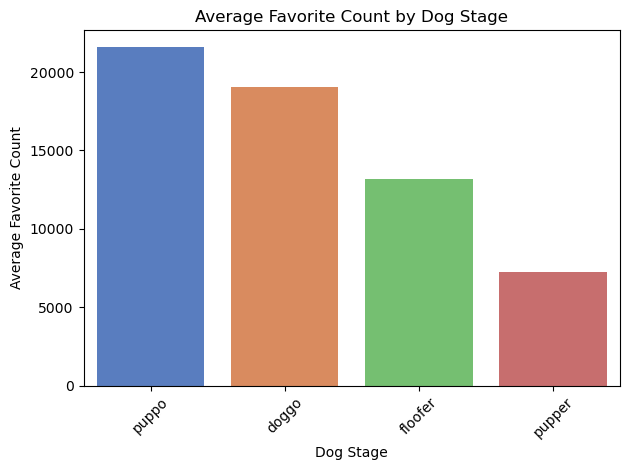

In [188]:
sns.barplot(x= stage_popularity.index, y=stage_popularity.values, palette='muted')
plt.title('Average Favorite Count by Dog Stage')
plt.ylabel('Average Favorite Count')
plt.xlabel('Dog Stage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

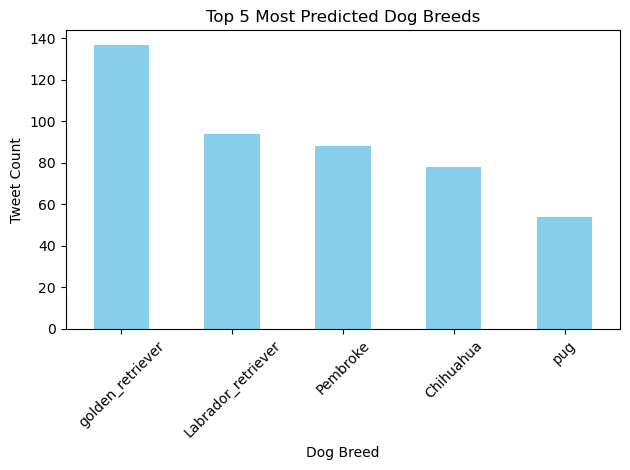

In [189]:
top_breeds.plot(kind='bar', color='skyblue')
plt.title('Top 5 Most Predicted Dog Breeds')
plt.ylabel('Tweet Count')
plt.xlabel('Dog Breed')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

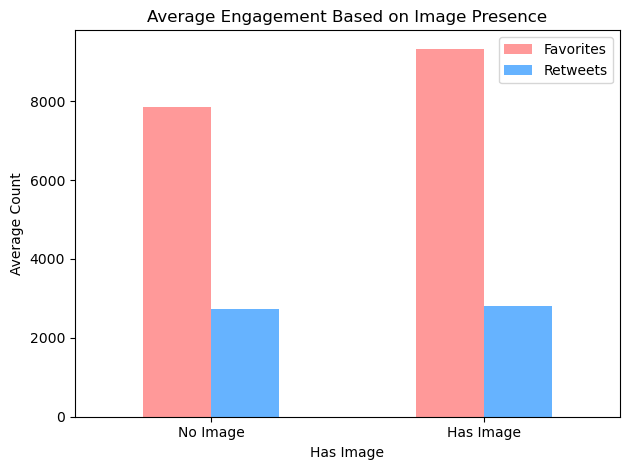

In [190]:
engagement.plot(kind='bar', color=['#ff9999', '#66b3ff'])
plt.title('Average Engagement Based on Image Presence')
plt.ylabel('Average Count')
plt.xlabel('Has Image')
plt.xticks(ticks=[0, 1], labels=['No Image', 'Has Image'], rotation=0)
plt.legend(['Favorites', 'Retweets'])
plt.tight_layout()
plt.show()